# 시계열

## 1. 데이터 불러오기

In [23]:
#uv add yfinance
import yfinance as yf
from datetime import date, timedelta

#날짜 설정하기
year = 5
today = date.today() # 오늘 날짜
end_date = date.today().strftime("%Y-%m-%d") #오늘 날짜를 문자열로 변환
start_date = today - timedelta(days=365*year) # 5년전 날짜
print(start_date, end_date)

# 데이터 다운로드
samsung = yf.download(
    tickers = '000660.KS',
    start = start_date,
    end = end_date)

samsung.head()

2020-09-09 2025-09-08


C:\Users\user\AppData\Local\Temp\ipykernel_46820\537810861.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  samsung = yf.download(
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,000660.KS,000660.KS,000660.KS,000660.KS,000660.KS
Date,,,,,
2020-09-09,72750.687500,73785.949547,72656.572768,73315.375889,3918435
2020-09-10,72091.898438,73597.734436,72091.898438,73409.504936,3541520
2020-09-11,73785.945312,73880.060039,71809.536063,72185.994968,2831262
2020-09-14,75291.804688,75385.919443,74256.542373,74444.771885,4099644
2020-09-15,77079.968750,77268.198222,75480.018239,76515.280334,5899410


In [24]:
samsung.columns = samsung.columns.droplevel(1)
samsung.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2020-09-09,72750.687500,73785.949547,72656.572768,73315.375889,3918435
2020-09-10,72091.898438,73597.734436,72091.898438,73409.504936,3541520
2020-09-11,73785.945312,73880.060039,71809.536063,72185.994968,2831262
2020-09-14,75291.804688,75385.919443,74256.542373,74444.771885,4099644
2020-09-15,77079.968750,77268.198222,75480.018239,76515.280334,5899410


In [25]:
samsung.tail()

Price,Close,High,Low,Open,Volume
Date,,,,,
2025-09-01,256000.0,261000.0,255000.0,259500.0,1837054
2025-09-02,260500.0,261500.0,256000.0,256000.0,1584710
2025-09-03,262500.0,265500.0,257750.0,259500.0,2437896
2025-09-04,265500.0,271000.0,264500.0,267000.0,2189959
2025-09-05,273500.0,275000.0,272000.0,273000.0,3103427


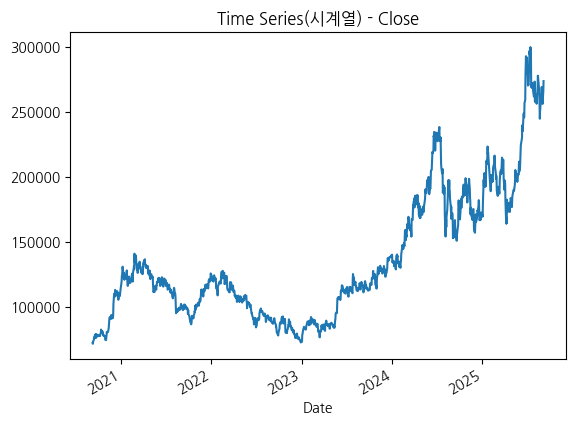

In [26]:
# 데이터 시각화하기
import matplotlib.pyplot as plt
import koreanize_matplotlib

samsung["Close"].plot()
plt.title("Time Series(시계열) - Close")
plt.show()

In [27]:
# Prophet 을 사용하기 위한 데이터 형태
# Columns: ds(날짜), y(close)

df = samsung.reset_index()[['Date', 'Close']]
df.columns = ["ds", "y"]
#df = df.rename(columns={"Date":"ds", "Close":"y"})
df

,ds,y
0,2020-09-09,72750.687500
1,2020-09-10,72091.898438
2,2020-09-11,73785.945312
3,2020-09-14,75291.804688
4,2020-09-15,77079.968750
...,...,...
1218,2025-09-01,256000.000000
1219,2025-09-02,260500.000000
1220,2025-09-03,262500.000000
1221,2025-09-04,265500.000000


## 2. Prophet

In [28]:
#uv add prophet
from prophet import Prophet

prophet = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=True)
prophet.fit(df)

10:11:59 - cmdstanpy - INFO - Chain [1] start processing
10:12:00 - cmdstanpy - INFO - Chain [1] done processing


In [29]:
# 향후 1년 예측
result = prophet.make_future_dataframe(periods=365)
forecast = prophet.predict(result)
forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]]

,ds,yhat,yhat_lower,yhat_upper
0,2020-09-09,78326.961953,63515.021689,93978.789575
1,2020-09-10,78185.672085,62251.646679,93397.595424
2,2020-09-11,77605.133330,62157.575537,94064.270908
3,2020-09-14,76563.312163,60696.808221,91016.258815
4,2020-09-15,76952.477368,61430.605072,90719.372757
...,...,...,...,...
1583,2026-09-01,308886.623816,250679.400633,368783.768827
1584,2026-09-02,308226.807823,248184.613186,370720.519382
1585,2026-09-03,307845.443890,249374.825998,368718.496688
1586,2026-09-04,306957.385146,245978.624021,364921.927805


## 3. prophet 시각화

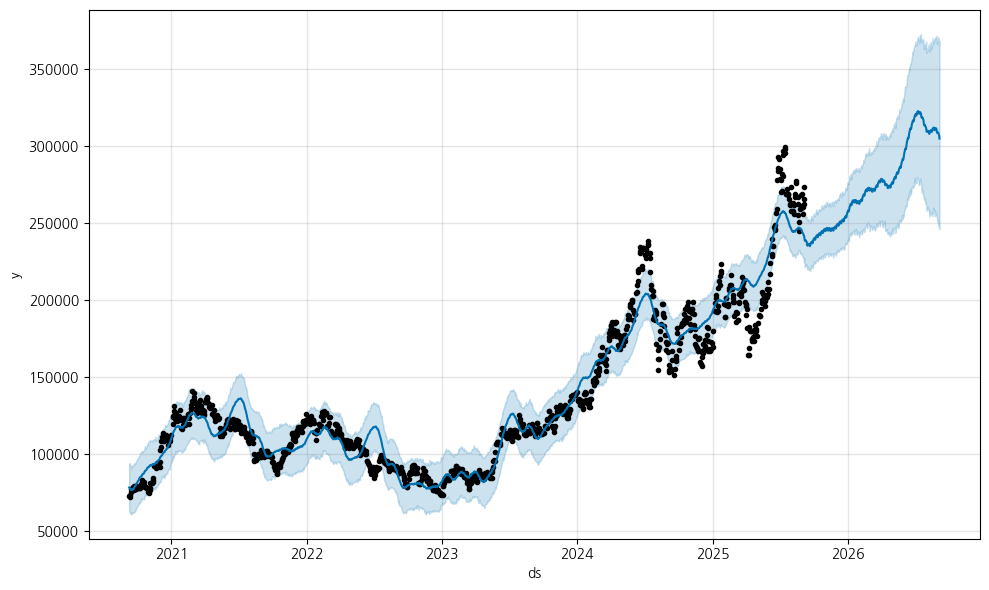

In [30]:
prophet.plot(forecast)
plt.show()

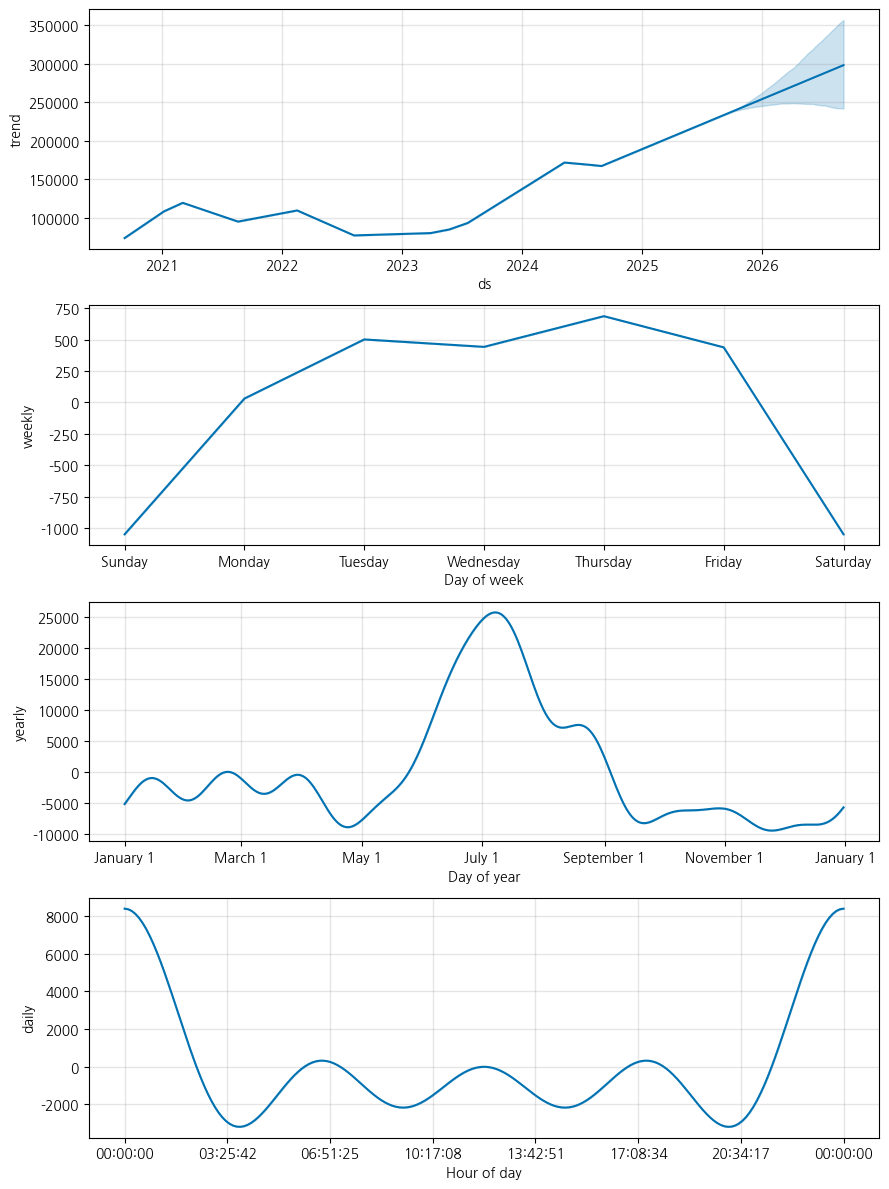

In [31]:
prophet.plot_components(forecast)
# Yearly seasonality

# Weekly seasonality

# Daily seasonality
plt.show()

# 외생변수가 많아서 패턴을 맞추기 어렵다


In [32]:
# holiday 설정하기

from prophet.make_holidays import make_holidays_df

holidays = make_holidays_df(
    year_list = [2020, 2021, 2022, 2023, 2024],
    country="KR"
)
holidays

,ds,holiday
0,2020-01-01,New Year's Day
1,2020-01-25,Korean New Year
2,2020-01-24,The day preceding Korean New Year
3,2020-01-26,The second day of Korean New Year
4,2020-03-01,Independence Movement Day
...,...,...
87,2024-12-25,Christmas Day
88,2024-04-10,National Assembly Election Day
89,2024-02-12,Alternative holiday for Korean New Year
90,2024-05-06,Alternative holiday for Children's Day


In [33]:
prophet = Prophet(holidays=holidays, yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=True)
prophet.fit(df)

10:17:31 - cmdstanpy - INFO - Chain [1] start processing
10:17:32 - cmdstanpy - INFO - Chain [1] done processing


In [34]:
# 향후 1년 예측
result = prophet.make_future_dataframe(periods=365)
forecast = prophet.predict(result)
forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]]

,ds,yhat,yhat_lower,yhat_upper
0,2020-09-09,77933.630556,62777.932340,93940.753564
1,2020-09-10,77797.171851,63477.238496,93548.216379
2,2020-09-11,77232.329882,61608.621418,91973.915945
3,2020-09-14,76218.544369,60355.020160,91974.828819
4,2020-09-15,76609.251285,60700.172208,92465.283763
...,...,...,...,...
1583,2026-09-01,309881.847689,249554.992813,374935.292606
1584,2026-09-02,309238.184171,247748.922626,372621.069443
1585,2026-09-03,308859.540539,247790.410925,373610.321955
1586,2026-09-04,307986.101144,247426.200764,370857.863032


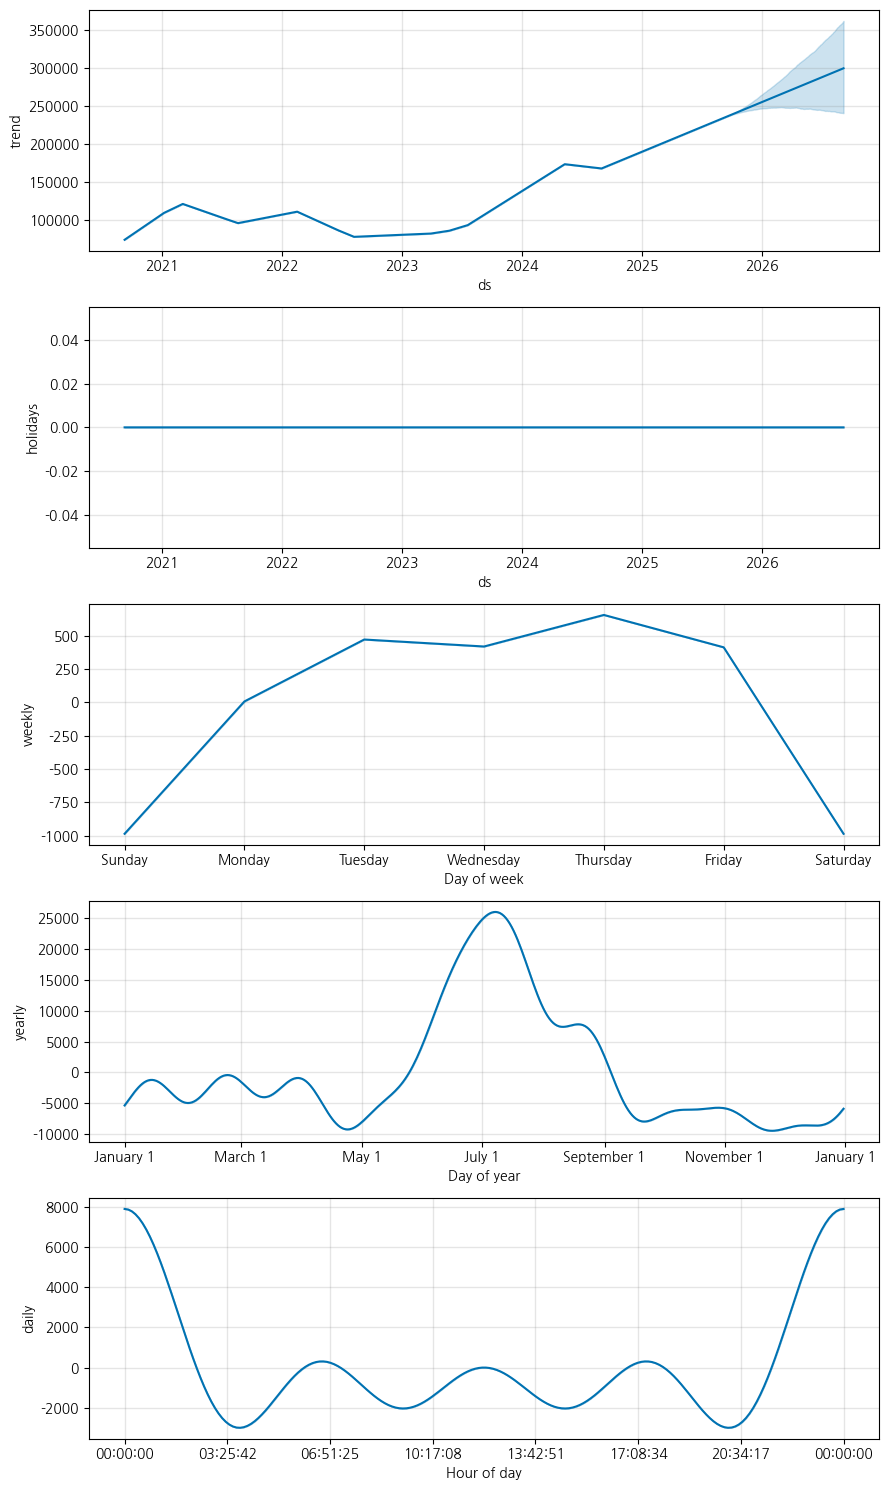

In [35]:
prophet.plot_components(forecast)
# Yearly seasonality

# Weekly seasonality

# Daily seasonality
plt.show()

# 외생변수가 많아서 패턴을 맞추기 어렵다
